# Basic use of the oimDisco component

This is a basic example showing the main features of the oimDisco component:

- Creation of the component
- computing and displaying chromatic images
- Computing and plotting chromatic visibilities
- Computing Spectral Energy Distribution (SED)
- Combining the oimDisco with other models (simulating a binary Be star)


### The DISCO model

The DISCO model is a semi-physical model of the continuum emission from a star surrounded by a gaseous circumstellar disk emitting free-free and bound-free emission. 

The disk is assumed to be partially ionized and geometrically thin, with a physical structure given by the viscous Keplerian decretion disk model and depending on physical input parameters (e.g. temperature, density).

It was created by A. Domiciano de Souza based on the work of Rodrigo G. Vieira.

the model is described in the following articles:

- [The pseudo-photosphere model for the continuum emission of gaseous disks](https://ui.adsabs.harvard.edu/abs/2015MNRAS.454.2107V/abstract) R. G. Vieira, A. C. Carciofi and J. E. Bjorkman MNRAS 454, 2107-2119 (2015)
- [Non-isothermal effects on Be disks](https://ui.adsabs.harvard.edu/abs/2016ASPC..506..135V/abstract) R. G. Vieira, A. C. Carciofi and J. E. Bjorkman ASPC 506, 135-142 (2016)
  
DISCO can produced polychromatic image cubes of the stellar photosphere (partially occulted) dans disc free-free and bound-free disk emission as well as SED.

In the current implementation in **oimodeler**, the star is modelled as a spherical blackbody (future updates will include other emission profile and non-spherical deformation due to fast-rotation)

DISCO is well suited to model classical Be stars, but can also be used to model other objects with similar physical components such as accretion disc of YSO, provided it is combined with some dust model disk model.


### Creating a DISCO model

We start by some basic imports and setting of the path.

In [4]:
from pathlib import Path
import os
import astropy.units as u
import oimodeler as oim
import matplotlib.pyplot as plt
import numpy as np
from astropy.modeling.models import BlackBody

path = Path(os.getcwd()).parents[3] # oimodeler package root path

We create a DISCO **oimDisco** component and a **oimModel** containing it

In [6]:
disc=oim.oimDisco(
    dim    = 256,     # dimension of the image (pixels)
    Rstar  = 5,      # Stellar Radius (Rsun)
    Mstar  = 10,      # Stellar Mass (Msun)
    Teff   = 20000,   # Effective Temperature (K)
    incl   = 70,      # inclination angle (deg)
    dist   = 100,     # distance (pc)
    Rd     = 50,      # Disk outer radius (Rsun) => this also define the fov of inner image
    Td0    = 15000,   # Temperature at the disk basis (K)
    powTd  = 0,       # Power law coefficient for disk temperature (0 mean isothermal disk) 
    rho0   = 2e-8,    # Density at disk basis (kg/m3)
    powRho = -3.5,      # Power law coefficient for disk density (-3.5 for static disc under viscous disc model)
    powHd  = 1.5,      # Power-law coefficient of disk flaring (1.5 is for standard model)
    ionfrac= 1        # Ionization fraction (1 <=> fully ionized)
)
m = oim.oimModel(disc)


oimodeler Acknowledgement Warning:

The DISCO model was created by A. Domiciano de Souza based on the work of Rodrigo G. Vieira.
Check the oimodeler page for proper refrence and acknowledgment : 
https://oimodeler.readthedocs.io/en/latest/ackn.html#acknowledgment


### Displaying chromatic images

As for any component, we can display the DISCO model uising the **showModel** method of the **oimModel** class.

However, unlike basic components (e.g. as **oimUD**, **oimGaussian**, **oimRing**) which are defined in the Fourier plan and derived from the **oimComponentFourier** class, the **oimDisco** component is defined in the image plan and derived from the **oimComponentimage** class.

Check the documentation on [image-based components](https://oimodeler.readthedocs.io/en/latest/models.html#image-components) in oimodeler.


The component computes images with it own internal grid. The spatial grid is determined:
- by the component parameter **dim**, which defines the number of pixels of the internal image and was set to 256 in our case
- the parameters **Rd** and **dist**, which allows to compute the angular pixel size in radian or mas.

The internal image pixelSize can be retrieved (in radian or mas) using the **getPixelSize** method of the oim


In [8]:
pixmas = disc.getPixelSize(mas=True)
print(f"The pixel size is {pixmas:.3f} mas")

The pixel size is 0.018 mas


The spectral grid, which defined the wavelengths of the reference images, is accessible through the **_wl** member variable of the class.

In [10]:
print(disc._wl)
print(disc._wl.size)

[1.00000000e-07 1.19086373e-07 1.41815643e-07 1.68883106e-07
 2.01116766e-07 2.39502662e-07 2.85215034e-07 3.39652240e-07
 4.04479534e-07 4.81680007e-07 5.73615251e-07 6.83097599e-07
 8.13476156e-07 9.68739251e-07 1.15363644e-06 1.37382380e-06
 1.63603693e-06 1.94829705e-06 2.32015629e-06 2.76298998e-06
 3.29034456e-06 3.91835201e-06 4.66622329e-06 5.55683609e-06
 6.61743456e-06 7.88046282e-06 9.38455736e-06 1.11757290e-05
 1.33087703e-05 1.58489319e-05]
30


By default, the oimDisco component internal wavelength grid contains 30 values logarithmically spaced between 0.1 and 15 $\mu$m.
This vector can be modified if needed.  Images and visibilities between these references wavlenegths are interpolated linearly. Extrapolation beyond this range is not performed and will result in an error.

Note that, the larger the internal wavelength grid is, the longer the computation time will be, but the more accurate the resulting images or visiblity computed will be. 

Now we can display some images from our model using the **showModel** method.

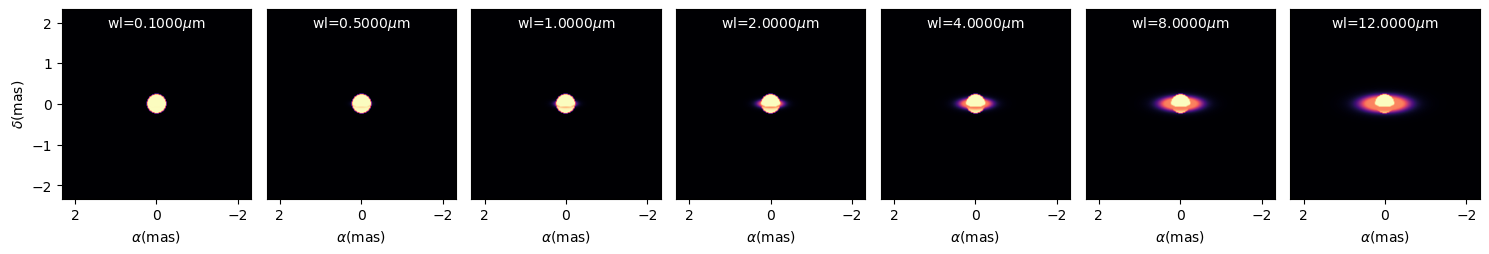

In [12]:
wl_im=np.array([0.1,0.5,1,2,4,8,12])*1e-6

fig, ax=plt.subplots(1,len(wl_im),figsize=(15,2.5))
_, _, im = m.showModel(disc.params["dim"].value,pixmas,fromFT=False,wl=wl_im,cmap="magma",
            legend=True,normalize=True,normPow=1,axe=ax,colorbar=False)
for axi in ax[1:]:
    axi.get_yaxis().set_visible(False)
fig.tight_layout()

### Computing and plotting chromatic visibilities

 Before computing the visibilities for our DISCO model we will create a uniform disk model of the same angular size than the stellar component of the DISCO model for comparison

In [15]:
D=2*disc.params["Rstar"].quantity.to(u.m).value
d= disc.params["dist"].quantity.to(u.m).value
theta=D/d*u.rad.to(u.mas)
ud = oim.oimUD(d=theta)
m2=oim.oimModel(ud)

We compute visibilities for this model using the **getComplexCoherentFlux** method for a set of 200 baselines ranging from 0 to 200m and for a wavelength of 0.5$\mu$m.

In [17]:
wl_ref = 0.5e-6
B_ref = np.linspace(0.0, 200, num=200)
spf_ref = B_ref/wl_ref

vis0 = np.abs(m2.getComplexCoherentFlux(spf_ref, spf_ref*0))
vis0 /= np.max(vis0)

We now compute the DISCO model visbility for a set of East-West baselines:
- with 100 wavelengths logarithmically spaced between 0.5 ad 10$\mu$m.
- 1000 spatial frequencies from 0 to 1.5x the first zero of the of visiblity of the star.


In [19]:
nwl = 100
nspf = 1000

# first zero of the star used to define the spatial-frequency range
spf_res = 1.22 / (ud.params["d"].value * u.mas.to(u.rad)) 
spf = np.linspace(0, spf_res * 1.5, nspf)
wl = np.logspace(-6.3, -5, num=nwl)
spf_2D = np.tile(spf, (nwl, 1)).flatten()
wl_2D = np.transpose(np.tile(wl, (nspf, 1))).flatten()

vis = np.abs(m.getComplexCoherentFlux(spf_2D, spf_2D*0, wl_2D)).reshape(nwl, nspf)
vis /= np.outer(np.max(vis, axis=1), np.ones(nspf))


Finally we can plot DISCO chromatic visibilties with the ones from the reference uniform disk.

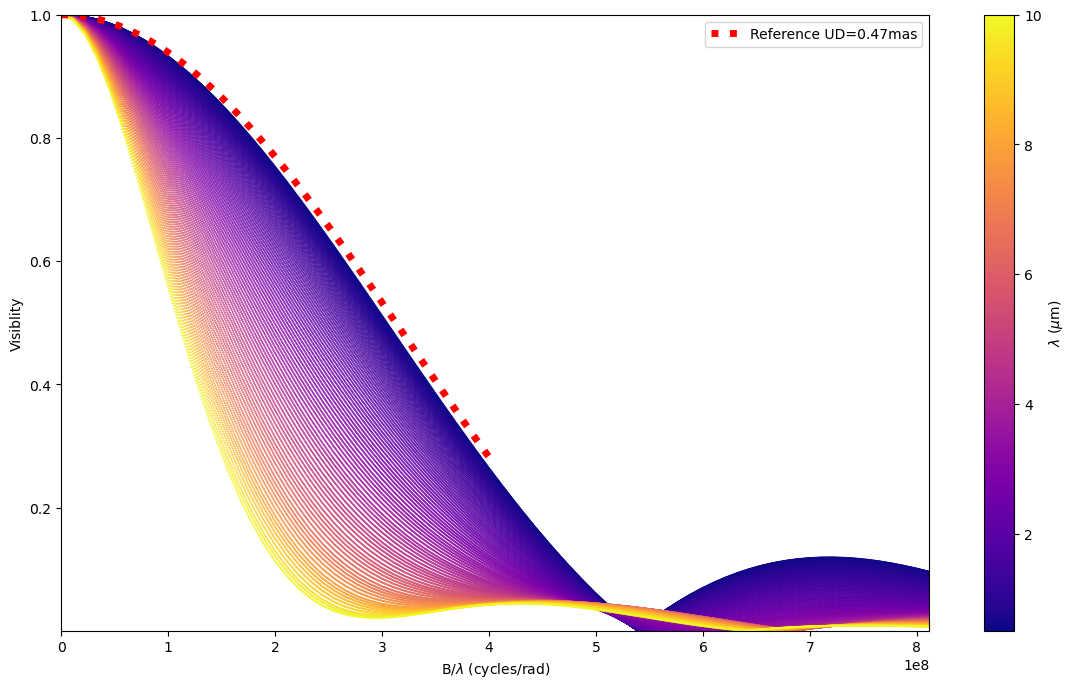

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
sc = ax.scatter(spf_2D, vis, c=wl_2D*1e6, s=0.2, cmap="plasma")
fig.colorbar(sc, ax=ax, label="$\\lambda$ ($\\mu$m)")
ax.set_xlabel("B/$\\lambda$ (cycles/rad)")
ax.set_ylabel("Visiblity")
ax.margins(0, 0)

ax.plot(spf_ref,vis0,color="r",ls=":",lw=5,label=f"Reference UD={ud.params["d"].value:.2f}mas")
ax.legend()


### Computing SED

To compute SED or use the **oimDisco** component for flux measurements, we must modify the default behavior of the **oimImageComponent**.

By default, the images computed by any **oimImageComponent** are flux normalized to ensure easy combination with other **oimodeler** components. For instance you could build a simple binary model with one **oimDisco** component and a point source (**oimPt**) and balance their fluxes using their **f** parameters.

Let's check this normalization by getting internal images using **dim**, **pixmas**, and **disc._wl**

To get the total flux for the chromatic image-cube we sum on the two last axes.


In [23]:
im0 = m.getImage(disc.params["dim"].value,pixmas,fromFT=False,wl=wl_im)
flx0 = np.sum(im0,axis=(1,2))

print(flx0)

[1. 1. 1. 1. 1. 1. 1.]


To enable absolute flux measurement we switch-off the image normalization using the **normalizeImage** variable member.

In [25]:
disc.normalizeImage=False

im = m.getImage(disc.params["dim"].value,pixmas,fromFT=False,wl=wl_im)
flx = np.sum(im,axis=(1,2))
print(flx)

[ 944.96390478 3158.73542352 1245.24027982  414.11745041  138.49049384
   50.24429282   29.2741409 ]


The **oimDisco** component returns fluxes in Jansky by default, but this can be modified using the **outunit** variable. 
This variable either a text or an [astropy.units](https://docs.astropy.org/en/stable/units/index.html).

Let's switch it to SI unit : $W/m^{3}$ and compute the fluxes again.

In [27]:
disc.outunit = "W/m3"
im1 = m.getImage(disc.params["dim"].value,pixmas,fromFT=False,wl=wl_im)
flx1 = np.sum(im1,axis=(1,2))
print(flx1)

[2.78767594e-01 3.81571699e-02 3.75913711e-03 3.11524133e-04
 2.59352803e-05 2.34202263e-06 6.23425324e-07]


Let's plot some SED. But first, to improve the SED accuracy and avoid interpolation problems, let's modify the internal wavlength grid setting it to a 120 value vector logarithmically spaced between 0.1 and 15$\mu$m.

In [29]:
disc._wl=np.logspace(-7,-4.8,num=120)  

Now we can plot the SED in both $W/m^3$ and $Jy$. 

We also overplot a simple blackbody corresponding to the stellar emission and highlight the infared excess due to free-free and free-bound emission.

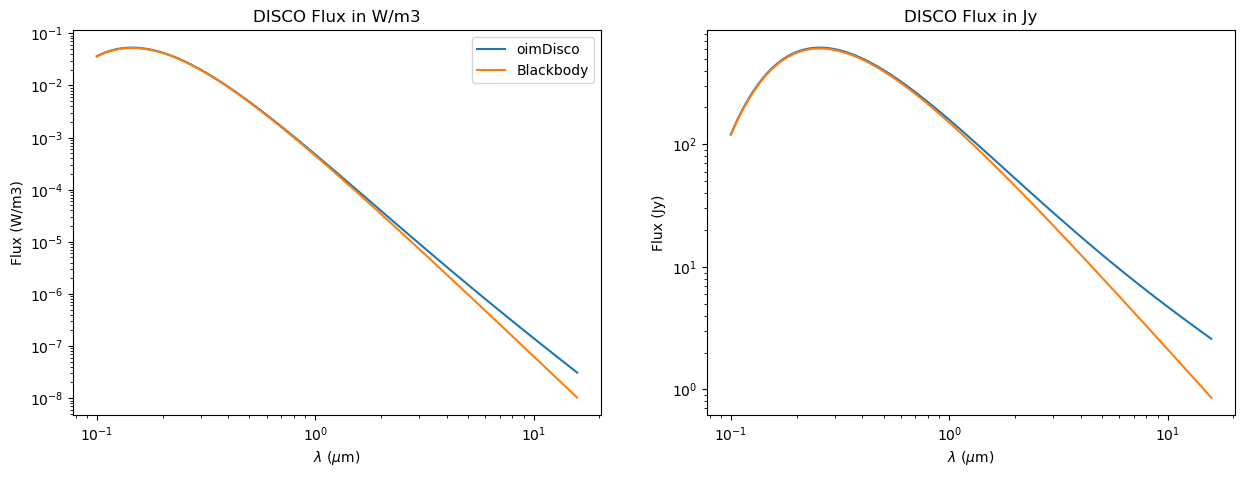

In [42]:

units=["W/m3","Jy"]
fig,ax = plt.subplots(1,2,figsize=(15,5))
for i,unit in enumerate(units):
    disc.outunit=unit
    wl_sed = disc._wl
    im= m.getImage(disc.params["dim"].value,pixmas,fromFT=False,wl=wl_sed)
    flx= np.sum(im,axis=(1,2))
    
    ax[i].loglog(wl_sed*1e6,flx,label="oimDisco")
    ax[i].set_xlabel("$\\lambda$ ($\\mu$m)")
    ax[i].set_ylabel(f"Flux ({disc.outunit})")
    
    bb = BlackBody(disc.params["Teff"].quantity)
    flx_bb = (bb(wl_sed*u.m)*np.pi*u.sr*(disc.params["Rstar"].quantity)**2/(disc.params["dist"].quantity)**2)
    flx_bb = flx_bb.to(disc.outunit,equivalencies=u.spectral_density(wl_sed*u.m))
    
    ax[i].plot(wl_sed*1e6,flx_bb,label="Blackbody")
    ax[i].set_title(f"DISCO Flux in {unit}")
    
ax[0].legend()   

### Combining the DISCO component to build a Binary Be star model

Some classical Be stars have a companion that can either be a main sequence star or compact source (such as white dwarf or neutron star).

Using oimodeler and the oimDisco component we can define a binary model consisting of :
- **B2.5Ve**:  5R$_\odot$ 20000K primary Be star surrounding by a dense circumstellar gaseous disk
- **B7V**  3.3R$_\odot$ 12000  companion modeled as a uniform disk located at 3 mas East of the primary.

We already have our DISCO component for the Be star. 

For the companion we will use:
- a UD disk component **oimUD**
- with a realistic blackbody flux in Jy using the **starWl** interpolator

The  **starWl** interpolator takes three parameters:
- **temp**: the effective temperature (K)
- **radius**: the physical radius (R$_\odot$)
- **dist**: the distance (pc)

We link the distance to the distance in the **oimDisco** component.

In [99]:
ud = oim.oimUD(f=oim.oimInterp("starWl", temp=12000,  radius=3.3), d = 0.3, x= 3, y =0)
ud.params["f"].dist = disc.params["dist"]

Let's verify the fluxes. We already have the primary fluxes (including the circumstellar disc) in Jansky.

We need to compute the secondary fluxes using the **ud.params["f"]** parameter interpolator with the same wavelengths.

In [102]:
flx_comp = ud.params["f"](wl_sed)

Finally we can plot both fluxes (+ the reference blackbody for the primary)

Text(0, 0.5, 'Flux (Jy)')

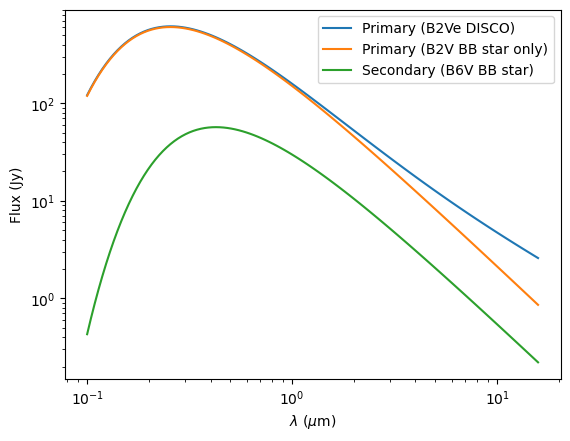

In [105]:
fig, ax = plt.subplots()

ax.loglog( wl_sed * 1e6, flx,   label="Primary (B2Ve DISCO)")
ax.plot( wl_sed * 1e6, flx_bb,  label="Primary (B2V BB star only)")
ax.plot(wl_sed * 1e6, flx_comp, label="Secondary (B6V BB star)")
ax.legend()
ax.set_yscale("log")
ax.set_xlabel("$\\lambda$ ($\\mu$m)")
ax.set_ylabel("Flux (Jy)")

Let's build a model with these two component.

In [108]:
mbin = oim.oimModel(disc,ud)

We can now show images from this model.

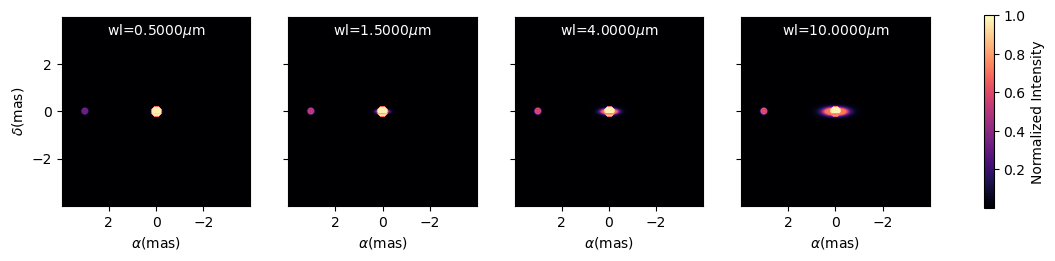

In [114]:
disc.params["dim"].value=128
pixmas = disc.getPixelSize(mas=True)
fov_model = 8
dim_model=int(fov_model/pixmas)
pix_model = pixmas

wl_im=np.array([0.5,1.5,4,10])*1e-6

fig,ax,im = mbin.showModel(dim_model,pix_model,wl=wl_im,fromFT=True,colorbar=True,normPow=1,legend=True,normalize=True,cmap="magma")


 Finally we compute some chromatic visibilities for East-West some baselines.

In [116]:
nwl = 100
nspf = 1000

# first zero of the star used to define the spatial-frequency range
spf_res = 1.22 / (ud.params["d"].value * u.mas.to(u.rad)) 
spf = np.linspace(0, spf_res , nspf)
wl = np.logspace(-6.3, -5, num=nwl)
spf_2D = np.tile(spf, (nwl, 1)).flatten()
wl_2D = np.transpose(np.tile(wl, (nspf, 1))).flatten()

visbin = np.abs(mbin.getComplexCoherentFlux(spf_2D, spf_2D*0, wl_2D)).reshape(nwl, nspf)
visbin /= np.outer(np.max(visbin, axis=1), np.ones(nspf))


And we plot the results

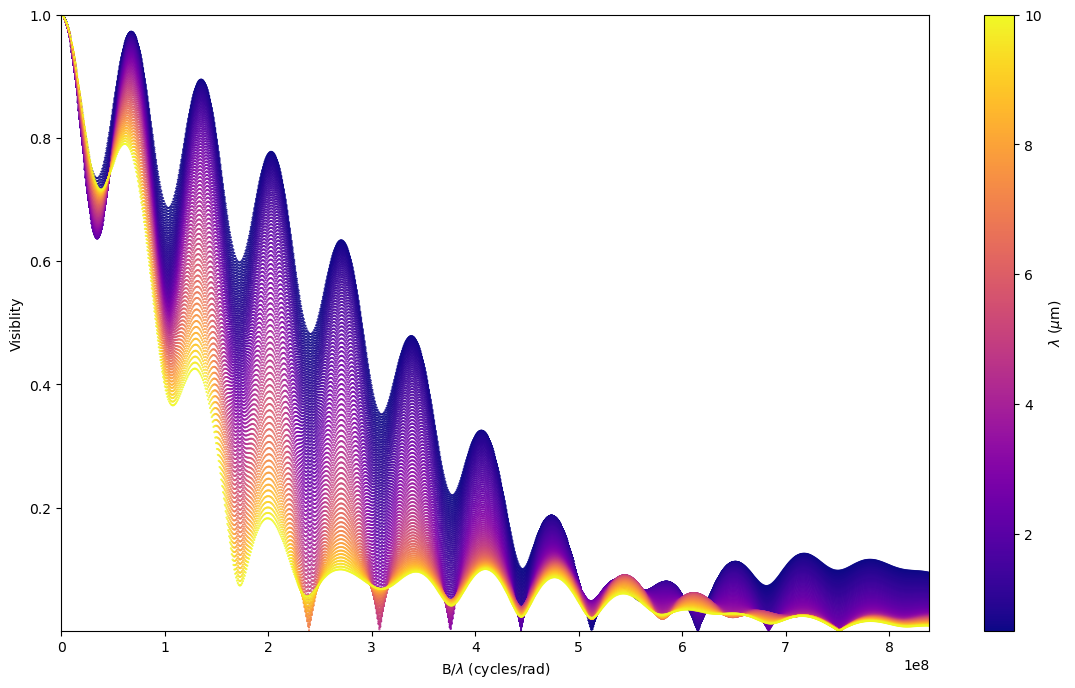

In [122]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))
sc = ax.scatter(spf_2D, visbin, c=wl_2D*1e6, s=0.2, cmap="plasma")
fig.colorbar(sc, ax=ax, label="$\\lambda$ ($\\mu$m)")
ax.set_xlabel("B/$\\lambda$ (cycles/rad)")
ax.set_ylabel("Visiblity")
ax.margins(0, 0)